Rozważmy model wytrenowany na datasecie `random`, tzn. na macierzach $SJS^{-1}$, gdzie $S$ jest generowana przez `np.random.rand()`.

Weźmy teraz macierz $ T = S (J + \Delta) S^{-1} $ z pewną macierzą Jordana $J$ o nietrywialnej klatce. Taka macierz jest (z reguły) diagonalizowalna, ponieważ diagonalizowalne są gęste w $\R^{d\times d}$, jednak u nas w datasecie testowym `perturbed` jest sklasyfikowana inaczej. Ponieważ mamy accuracy `>60%` na takim zestawie danych treningowych i testowych, macierz ta z dużym prawdopodobieństwem zostanie sklasyfikowana poprawnie z punktu widzenia dataestu testowego. Czyli w rzeczywistości niepoprawnie -- bo przecież trenowaliśmy model, by w takiej sytuacji zaklasyfikował macierz jako diagonalizowalną. 

Co więcej, model wytrenowany na datasecie bez perturbacji zachowuje się dokładnie tak samo, jak model wytrenowany do "radzenia" sobie z takimi perturbacjami. Sensowny byłby zatem wniosek: model wytrenowany nawet na datasecie bez tych perturbacji, i tak przewiduje, czy w pewnym otoczeniu danej macierzy $T$ znajduje się macierz o nietrywialnej klatce Jordana.

No ale przecież wiemy z poprzednich rozważań, że wokół każdej macierzy (o ile tylko występuje wielokrotna wartość własna - a tu występuje) w dowolnym otoczeniu znajdzie się zarówno diagonalizowalna, jak i taka z dowolnie dużą klatką (czy też różnicą między wielokrotnością algebraiczną a geometryczną). Wg mnie decydująca tutaj jest $\kappa(S)$. Konstruowanie tych macierzy w moim dowodzie z poprzedniego maila wymaga $\kappa(S) \rightarrow \infty$ gdy $ \varepsilon \rightarrow 0$. A u nas w danych treningowych $\kappa(S)$ była ograniczona. 

Być może sensowne więc będzie postawienie takiego problemu:
> Dla zadanych $T \in \R^{d \times d}, \varepsilon > 0, K > 0$: czy w $\varepsilon$-otoczeniu $T$ znajduje się macierz $T'$ o nietrywialnej klatce Jordana, taka że $T' = SJS^{-1}$ i $\kappa(S) < K$?

W poniższych tabelach: label oznacza róznicę między wielokrotnością algebraiczną a geometryczną wartości własnej. Tzn. macierze oznaczone jako "0" są diagonalizowalne, te z "1" mają jedną 1 nad przekątną w postaci Jordana itd.

### Confusion matrix dla trenowania na `random` i testowania na `perturbed`

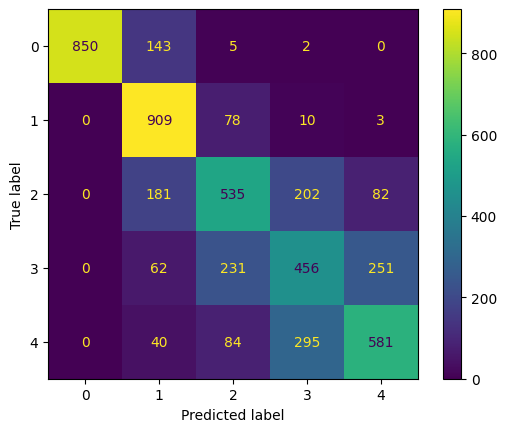

In [ ]:
ConfusionMatrixDisplay(cm).plot()

To wydaje mi się ciekawe. Skoro model został wytrenowany do predykcji na dokładnych macierzach, to spodziewałbym się takiego błędu: wkładamy zaburzoną macierz o nietrywialnej klatce Jordana, ale przez zaburzenie oddaliła się na tyle od tamtej macierzy, że nasz model i tak klasyfikuje ją jako 0 (diagonalizowalną). A takich przypadków jest 0. 

Z kolei są przypadki odwrotne (143): mamy diagonalizowalną macierz $J$, zaubrzamy ją i nagle $T = S(J+\Delta)S^{-1}$ wpada przez przypadek na tyle blisko jakiejś nietrywialnej klatki, że model klasyfikuje to jako 1 (czyli nietrywialną klatkę). A wydawałoby się, że to nie powinno mieć miejsca

### Confusion matrix dla trenowania na `perturbed` i testowania na `random`

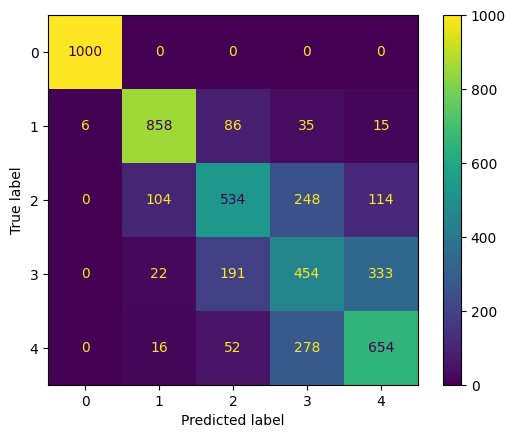

In [ ]:
ConfusionMatrixDisplay(cm).plot()